In [1]:
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import tensorflow as tf

# Project root
PROJECT_ROOT = Path(r"C:\Users\user\OneDrive\Desktop\CC Project clone\Ecommerce-purchase-prediction-DeepLearning")

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

Project root: C:\Users\user\OneDrive\Desktop\CC Project clone\Ecommerce-purchase-prediction-DeepLearning
TensorFlow version: 2.21.0
NumPy version: 2.5.3
Pandas version: 3.0.6


In [2]:
# Cell 2 — Load shared processed data and chronological split

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

MODEL_EVENTS_PATH = PROCESSED_DIR / "model_events.parquet"
LABELS_PATH = PROCESSED_DIR / "labels.csv"
SPLIT_IDS_PATH = PROCESSED_DIR / "split_ids.json"

print("Processed directory:", PROCESSED_DIR)

# Check required files
for path in [MODEL_EVENTS_PATH, LABELS_PATH, SPLIT_IDS_PATH]:
    print(f"{path.name}: {'FOUND' if path.exists() else 'MISSING'}")

# Load shared data
model_events = pd.read_parquet(MODEL_EVENTS_PATH)
labels = pd.read_csv(LABELS_PATH)

# Load chronological split IDs
import json

with open(SPLIT_IDS_PATH, "r", encoding="utf-8") as f:
    split_ids = json.load(f)

print("\nModel events:", model_events.shape)
print("Labels:", labels.shape)

print("\nSplit sizes:")
print("Train:", len(split_ids["train"]))
print("Validation:", len(split_ids["val"]))
print("Test:", len(split_ids["test"]))

Processed directory: C:\Users\user\OneDrive\Desktop\CC Project clone\Ecommerce-purchase-prediction-DeepLearning\data\processed
model_events.parquet: FOUND
labels.csv: FOUND
split_ids.json: FOUND

Model events: (2686671, 7)
Labels: (1760737, 2)

Split sizes:
Train: 1232515
Validation: 264110
Test: 264112


In [ ]:
# Cell 3 — Create session-level behavioral features

events = model_events.copy()

# Make sure datetime is in datetime format
events["datetime"] = pd.to_datetime(events["datetime"])

# Sort events within each session
events = events.sort_values(["session_id", "datetime"]).reset_index(drop=True)

# Calculate time difference between consecutive events
events["inter_event_seconds"] = (
    events.groupby("session_id")["datetime"]
    .diff()
    .dt.total_seconds()
)

# Create binary indicators
events["is_view"] = (events["event"] == "view").astype(int)
events["is_addtocart"] = (events["event"] == "addtocart").astype(int)

# Aggregate behavioral features for each session
session_features = (
    events.groupby("session_id")
    .agg(
        view_count=("is_view", "sum"),
        addtocart_count=("is_addtocart", "sum"),
        total_event_count=("event", "count"),
        unique_item_count=("itemid", "nunique"),
        session_duration_seconds=("datetime", lambda x: (x.max() - x.min()).total_seconds()),
        mean_inter_event_seconds=("inter_event_seconds", "mean"),
        max_inter_event_seconds=("inter_event_seconds", "max"),
    )
    .reset_index()
)

# Add behavioral ratio
session_features["addtocart_rate"] = (
    session_features["addtocart_count"]
    / session_features["total_event_count"]
)

# Replace undefined values
session_features = session_features.replace(
    [np.inf, -np.inf],
    np.nan
)

session_features = session_features.fillna(0)

print("Session features shape:", session_features.shape)
print("\nFeature columns:")
print(session_features.columns.tolist())

print("\nFirst 5 sessions:")
display(session_features.head())

Session features shape: (1760737, 9)

Feature columns:
['session_id', 'view_count', 'addtocart_count', 'total_event_count', 'unique_item_count', 'session_duration_seconds', 'mean_inter_event_seconds', 'max_inter_event_seconds', 'addtocart_rate']

First 5 sessions:


,session_id,view_count,addtocart_count,total_event_count,unique_item_count,session_duration_seconds,mean_inter_event_seconds,max_inter_event_seconds,addtocart_rate
0,0_1,3,0,3,3,327.736,163.868,170.152,0.0
1,1000000_1,1,0,1,1,0.000,0.000,0.000,0.0
2,1000001_1,1,0,1,1,0.000,0.000,0.000,0.0
3,1000001_2,3,0,3,3,1061.726,530.863,999.470,0.0
4,1000001_3,1,0,1,1,0.000,0.000,0.000,0.0


In [4]:
# Cell 4 — Attach labels and create exact train/validation/test datasets

# Merge the target labels with session-level features
session_data = session_features.merge(
    labels[["session_id", "target"]],
    on="session_id",
    how="inner",
    validate="one_to_one"
)

print("Session data shape:", session_data.shape)

# Convert split ID lists to sets for fast lookup
train_ids = set(split_ids["train"])
val_ids = set(split_ids["val"])
test_ids = set(split_ids["test"])

# Create exact splits using the shared foundation split IDs
train_data = session_data[session_data["session_id"].isin(train_ids)].copy()
val_data = session_data[session_data["session_id"].isin(val_ids)].copy()
test_data = session_data[session_data["session_id"].isin(test_ids)].copy()

print("\nSplit shapes:")
print("Train:", train_data.shape)
print("Validation:", val_data.shape)
print("Test:", test_data.shape)

# Check that there is no overlap
assert set(train_data["session_id"]).isdisjoint(val_data["session_id"])
assert set(train_data["session_id"]).isdisjoint(test_data["session_id"])
assert set(val_data["session_id"]).isdisjoint(test_data["session_id"])

print("\nSplit overlap check: PASSED")

# Check target distributions
print("\nTarget distribution:")

for name, df in [
    ("Train", train_data),
    ("Validation", val_data),
    ("Test", test_data)
]:
    print(f"\n{name}:")
    print(df["target"].value_counts().sort_index())
    print(df["target"].value_counts(normalize=True).sort_index())

Session data shape: (1760737, 10)

Split shapes:
Train: (1232515, 10)
Validation: (264110, 10)
Test: (264112, 10)

Split overlap check: PASSED

Target distribution:

Train:
target
0    1223084
1       9431
Name: count, dtype: int64
target
0    0.992348
1    0.007652
Name: proportion, dtype: float64

Validation:
target
0    262119
1      1991
Name: count, dtype: int64
target
0    0.992461
1    0.007539
Name: proportion, dtype: float64

Test:
target
0    262175
1      1937
Name: count, dtype: int64
target
0    0.992666
1    0.007334
Name: proportion, dtype: float64


In [5]:
# Cell 5 — Prepare feature matrices and target vectors

FEATURE_COLUMNS = [
    "view_count",
    "addtocart_count",
    "total_event_count",
    "unique_item_count",
    "session_duration_seconds",
    "mean_inter_event_seconds",
    "max_inter_event_seconds",
    "addtocart_rate"
]

TARGET_COLUMN = "target"

# Create X and y
X_train = train_data[FEATURE_COLUMNS].copy()
y_train = train_data[TARGET_COLUMN].copy()

X_val = val_data[FEATURE_COLUMNS].copy()
y_val = val_data[TARGET_COLUMN].copy()

X_test = test_data[FEATURE_COLUMNS].copy()
y_test = test_data[TARGET_COLUMN].copy()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nFeatures used:")
for i, feature in enumerate(FEATURE_COLUMNS, start=1):
    print(f"{i}. {feature}")

# Check for missing/infinite values
print("\nMissing values:")
print("Train:", X_train.isna().sum().sum())
print("Validation:", X_val.isna().sum().sum())
print("Test:", X_test.isna().sum().sum())

print("\nInfinite values:")
print("Train:", np.isinf(X_train.to_numpy()).sum())
print("Validation:", np.isinf(X_val.to_numpy()).sum())
print("Test:", np.isinf(X_test.to_numpy()).sum())

X_train: (1232515, 8)
y_train: (1232515,)
X_val: (264110, 8)
y_val: (264110,)
X_test: (264112, 8)
y_test: (264112,)

Features used:
1. view_count
2. addtocart_count
3. total_event_count
4. unique_item_count
5. session_duration_seconds
6. mean_inter_event_seconds
7. max_inter_event_seconds
8. addtocart_rate

Missing values:
Train: 0
Validation: 0
Test: 0

Infinite values:
Train: 0
Validation: 0
Test: 0


In [6]:
# Cell 6 — Feature scaling (fit on training data only)

scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same scaler to validation and test data
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaled feature shapes:")
print("X_train_scaled:", X_train_scaled.shape)
print("X_val_scaled:", X_val_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

# Verify scaling using training data
print("\nTraining feature means after scaling:")
print(np.mean(X_train_scaled, axis=0))

print("\nTraining feature standard deviations after scaling:")
print(np.std(X_train_scaled, axis=0))

Scaled feature shapes:
X_train_scaled: (1232515, 8)
X_val_scaled: (264110, 8)
X_test_scaled: (264112, 8)

Training feature means after scaling:
[-5.71886260e-18 -3.09003060e-17  2.23220121e-17  8.48605418e-18
 -2.73029569e-17  2.60116009e-17  4.94404896e-17  5.08240854e-17]

Training feature standard deviations after scaling:
[1. 1. 1. 1. 1. 1. 1. 1.]


In [7]:
# Cell 7 — Calculate class weights from training data only

from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = {
    int(cls): float(weight)
    for cls, weight in zip(classes, class_weights_array)
}

print("Classes:", classes)
print("Class weights:", class_weights)

print("\nTraining class distribution:")
print(y_train.value_counts().sort_index())

print("\nTraining class proportions:")
print(y_train.value_counts(normalize=True).sort_index())

Classes: [0 1]
Class weights: {0: 0.5038554179434936, 1: 65.34381295726858}

Training class distribution:
target
0    1223084
1       9431
Name: count, dtype: int64

Training class proportions:
target
0    0.992348
1    0.007652
Name: proportion, dtype: float64


In [8]:
# Cell 8 — Define the Deep MLP architecture

tf.keras.backend.clear_session()

tf.random.set_seed(42)
np.random.seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(len(FEATURE_COLUMNS),)),

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.30),

    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.30),

    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dropout(0.20),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,521 (45.00 KB)

 Trainable params: 11,521 (45.00 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Cell 9 — Compile the MLP model

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

print("Model compiled successfully.")

Model compiled successfully.


In [10]:
# Cell 10 — Define training callbacks

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_auc",
    mode="max",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

callbacks = [
    early_stopping,
    reduce_lr
]

print("Callbacks configured:")
print("- EarlyStopping: monitor=val_auc, patience=5")
print("- ReduceLROnPlateau: monitor=val_auc, factor=0.5, patience=2")

Callbacks configured:
- EarlyStopping: monitor=val_auc, patience=5
- ReduceLROnPlateau: monitor=val_auc, factor=0.5, patience=2


In [11]:
# Cell 11 — Train the Deep MLP

BATCH_SIZE = 2048
EPOCHS = 30

print("Starting MLP training...")
print(f"Training samples: {len(X_train_scaled):,}")
print(f"Validation samples: {len(X_val_scaled):,}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Maximum epochs: {EPOCHS}")

training_start_time = time.perf_counter()

history = model.fit(
    X_train_scaled,
    y_train.to_numpy(),
    validation_data=(
        X_val_scaled,
        y_val.to_numpy()
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

training_time = time.perf_counter() - training_start_time

print(f"\nTraining completed in {training_time:.2f} seconds")
print(f"Training time: {training_time / 60:.2f} minutes")
print(f"Epochs completed: {len(history.history['loss'])}")

Starting MLP training...
Training samples: 1,232,515
Validation samples: 264,110
Batch size: 2048
Maximum epochs: 30
Epoch 1/30
602/602 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9636 - auc: 0.9422 - loss: 0.2641 - precision: 0.1600 - recall: 0.8858 - val_accuracy: 0.9734 - val_auc: 0.9461 - val_loss: 0.1939 - val_precision: 0.2054 - val_recall: 0.8835 - learning_rate: 0.0010
Epoch 2/30
602/602 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9744 - auc: 0.9473 - loss: 0.2359 - precision: 0.2155 - recall: 0.8867 - val_accuracy: 0.9789 - val_auc: 0.9471 - val_loss: 0.1785 - val_precision: 0.2475 - val_recall: 0.8800 - learning_rate: 0.0010
Epoch 3/30
602/602 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9754 - auc: 0.9471 - loss: 0.2328 - precision: 0.2226 - recall: 0.8867 - val_accuracy: 0.9751 - val_auc: 0.9474 - val_loss: 0.1782 - val_precision: 0.2172 - val_recall: 0.8825 - learning_rate: 0.0010
Epoch 4/30
602/602 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9760 - auc: 0.9475 

In [12]:
# Cell 12 — Summarize training history

history_df = pd.DataFrame(history.history)

print("Epochs completed:", len(history_df))

print("\nBest validation AUC:")
best_auc_epoch = history_df["val_auc"].idxmax() + 1
best_val_auc = history_df["val_auc"].max()

print(f"Epoch: {best_auc_epoch}")
print(f"Validation AUC: {best_val_auc:.4f}")

print("\nBest validation loss:")
best_loss_epoch = history_df["val_loss"].idxmin() + 1
best_val_loss = history_df["val_loss"].min()

print(f"Epoch: {best_loss_epoch}")
print(f"Validation Loss: {best_val_loss:.4f}")

print("\nTraining history:")
display(history_df)

Epochs completed: 18

Best validation AUC:
Epoch: 13
Validation AUC: 0.9483

Best validation loss:
Epoch: 9
Validation Loss: 0.1743

Training history:


,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall,learning_rate
0,0.963551,0.942179,0.264101,0.160035,0.885802,0.973356,0.946086,0.193938,0.205395,0.883476,0.001000
1,0.974438,0.947286,0.235942,0.215527,0.886650,0.978925,0.947131,0.178489,0.247493,0.879960,0.001000
2,0.975444,0.947143,0.232830,0.222636,0.886650,0.975143,0.947442,0.178165,0.217235,0.882471,0.001000
3,0.975959,0.947458,0.230494,0.226287,0.885378,0.975597,0.947590,0.178530,0.220507,0.882471,0.001000
4,0.975874,0.947086,0.229968,0.225749,0.886120,0.977922,0.947644,0.181557,0.238562,0.879960,0.001000
5,0.976490,0.947176,0.228613,0.230406,0.885590,0.976820,0.947828,0.178551,0.229753,0.881969,0.001000
6,0.975477,0.946622,0.228584,0.222954,0.887181,0.970119,0.947727,0.180134,0.187348,0.887996,0.001000
7,0.975821,0.949068,0.226079,0.225220,0.885166,0.970569,0.947829,0.177692,0.189873,0.889000,0.001000
8,0.975474,0.948031,0.226067,0.222974,0.887499,0.975480,0.948117,0.174255,0.219723,0.882973,0.000500
9,0.975912,0.948322,0.225525,0.226110,0.886650,0.977244,0.948146,0.175539,0.233099,0.881467,0.000500


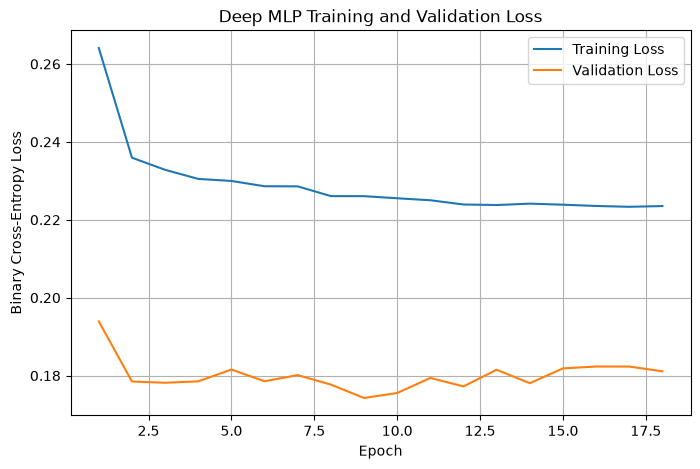

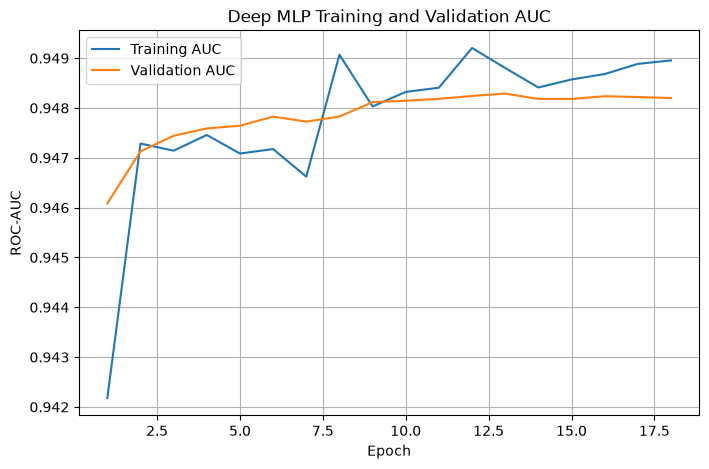

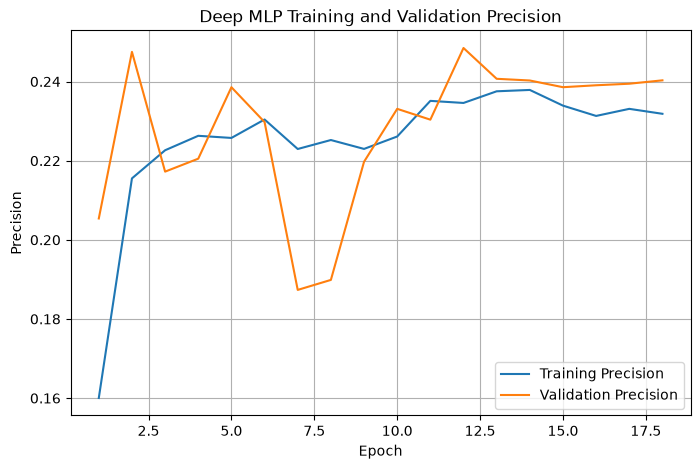

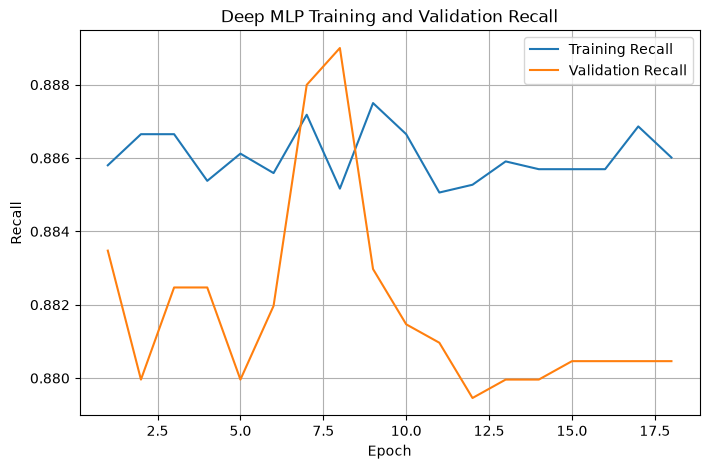

In [13]:
# Cell 13 — Plot training and validation performance

epochs_range = range(1, len(history.history["loss"]) + 1)

# Loss curve
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history.history["loss"], label="Training Loss")
plt.plot(epochs_range, history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Deep MLP Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# AUC curve
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history.history["auc"], label="Training AUC")
plt.plot(epochs_range, history.history["val_auc"], label="Validation AUC")
plt.xlabel("Epoch")
plt.ylabel("ROC-AUC")
plt.title("Deep MLP Training and Validation AUC")
plt.legend()
plt.grid(True)
plt.show()

# Precision curve
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history.history["precision"], label="Training Precision")
plt.plot(epochs_range, history.history["val_precision"], label="Validation Precision")
plt.xlabel("Epoch")
plt.ylabel("Precision")
plt.title("Deep MLP Training and Validation Precision")
plt.legend()
plt.grid(True)
plt.show()

# Recall curve
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history.history["recall"], label="Training Recall")
plt.plot(epochs_range, history.history["val_recall"], label="Validation Recall")
plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.title("Deep MLP Training and Validation Recall")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
# Cell 14 — Analyze classification thresholds using validation data

# Predict probabilities for validation set
val_probabilities = model.predict(
    X_val_scaled,
    batch_size=4096,
    verbose=1
).ravel()

threshold_results = []

thresholds = np.arange(0.10, 0.91, 0.05)

for threshold in thresholds:
    val_predictions = (val_probabilities >= threshold).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(
            y_val, val_predictions, zero_division=0
        ),
        "recall": recall_score(
            y_val, val_predictions, zero_division=0
        ),
        "f1": f1_score(
            y_val, val_predictions, zero_division=0
        ),
        "accuracy": accuracy_score(
            y_val, val_predictions
        )
    })

threshold_df = pd.DataFrame(threshold_results)

print("Validation threshold analysis:")
display(threshold_df.round(4))

# Select threshold with highest validation F1
best_threshold_row = threshold_df.loc[
    threshold_df["f1"].idxmax()
]

BEST_THRESHOLD = float(best_threshold_row["threshold"])

print("\nSelected threshold based on validation F1:")
print(f"Threshold: {BEST_THRESHOLD:.2f}")
print(f"Validation F1: {best_threshold_row['f1']:.4f}")
print(f"Validation Precision: {best_threshold_row['precision']:.4f}")
print(f"Validation Recall: {best_threshold_row['recall']:.4f}")
print(f"Validation Accuracy: {best_threshold_row['accuracy']:.4f}")

65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Validation threshold analysis:


,threshold,precision,recall,f1,accuracy
0,0.10,0.0343,0.9312,0.0661,0.8018
1,0.15,0.0499,0.9237,0.0947,0.8669
2,0.20,0.0653,0.9181,0.1219,0.9003
3,0.25,0.0858,0.9106,0.1568,0.9261
4,0.30,0.1398,0.8960,0.2419,0.9577
5,0.35,0.1578,0.8935,0.2683,0.9633
6,0.40,0.1792,0.8910,0.2983,0.9684
7,0.45,0.2129,0.8845,0.3432,0.9745
8,0.50,0.2407,0.8800,0.3780,0.9782
9,0.55,0.2542,0.8790,0.3943,0.9796



Selected threshold based on validation F1:
Threshold: 0.90
Validation F1: 0.4034
Validation Precision: 0.2618
Validation Recall: 0.8785
Validation Accuracy: 0.9804


In [15]:
# Cell 15 — Fine-grained threshold search on validation set

fine_thresholds = np.arange(0.90, 1.00, 0.01)

fine_results = []

for threshold in fine_thresholds:
    val_predictions = (val_probabilities >= threshold).astype(int)

    fine_results.append({
        "threshold": threshold,
        "precision": precision_score(
            y_val, val_predictions, zero_division=0
        ),
        "recall": recall_score(
            y_val, val_predictions, zero_division=0
        ),
        "f1": f1_score(
            y_val, val_predictions, zero_division=0
        ),
        "accuracy": accuracy_score(
            y_val, val_predictions
        )
    })

fine_threshold_df = pd.DataFrame(fine_results)

print("Fine-grained validation threshold analysis:")
display(fine_threshold_df.round(4))

best_threshold_row = fine_threshold_df.loc[
    fine_threshold_df["f1"].idxmax()
]

BEST_THRESHOLD = float(best_threshold_row["threshold"])

print("\nFinal threshold selected using validation F1:")
print(f"Threshold: {BEST_THRESHOLD:.2f}")
print(f"Validation F1: {best_threshold_row['f1']:.4f}")
print(f"Validation Precision: {best_threshold_row['precision']:.4f}")
print(f"Validation Recall: {best_threshold_row['recall']:.4f}")
print(f"Validation Accuracy: {best_threshold_row['accuracy']:.4f}")

Fine-grained validation threshold analysis:


,threshold,precision,recall,f1,accuracy
0,0.90,0.2618,0.8785,0.4034,0.9804
1,0.91,0.2621,0.8780,0.4037,0.9805
2,0.92,0.2624,0.8764,0.4039,0.9805
3,0.93,0.2627,0.8759,0.4042,0.9805
4,0.94,0.2632,0.8734,0.4045,0.9806
5,0.95,0.2646,0.8684,0.4056,0.9808
6,0.96,0.2693,0.8574,0.4099,0.9814
7,0.97,0.2921,0.7549,0.4212,0.9844
8,0.98,0.3244,0.5696,0.4133,0.9878
9,0.99,0.4397,0.0256,0.0484,0.9924



Final threshold selected using validation F1:
Threshold: 0.97
Validation F1: 0.4212
Validation Precision: 0.2921
Validation Recall: 0.7549
Validation Accuracy: 0.9844


In [16]:
# Cell 16 — Final test-set prediction using the frozen validation threshold

print("Final evaluation threshold:", BEST_THRESHOLD)

test_start_time = time.perf_counter()

test_probabilities = model.predict(
    X_test_scaled,
    batch_size=4096,
    verbose=1
).ravel()

test_inference_time = time.perf_counter() - test_start_time

test_predictions = (
    test_probabilities >= BEST_THRESHOLD
).astype(int)

print("\nTest prediction completed.")
print(f"Test inference time: {test_inference_time:.4f} seconds")
print(f"Test samples: {len(test_predictions):,}")
print(f"Positive predictions: {test_predictions.sum():,}")
print(f"Negative predictions: {(test_predictions == 0).sum():,}")

Final evaluation threshold: 0.9700000000000001
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Test prediction completed.
Test inference time: 0.1724 seconds
Test samples: 264,112
Positive predictions: 4,866
Negative predictions: 259,246


In [17]:
# Cell 17 — Final test-set evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

test_accuracy = accuracy_score(y_test, test_predictions)
test_precision = precision_score(
    y_test, test_predictions, zero_division=0
)
test_recall = recall_score(
    y_test, test_predictions, zero_division=0
)
test_f1 = f1_score(
    y_test, test_predictions, zero_division=0
)
test_roc_auc = roc_auc_score(
    y_test, test_probabilities
)

test_cm = confusion_matrix(
    y_test,
    test_predictions
)

print("=" * 60)
print("FINAL TEST-SET EVALUATION — DEEP MLP")
print("=" * 60)

print(f"Threshold:        {BEST_THRESHOLD:.2f}")
print(f"Accuracy:         {test_accuracy:.4f}")
print(f"Precision:        {test_precision:.4f}")
print(f"Recall:           {test_recall:.4f}")
print(f"F1-score:         {test_f1:.4f}")
print(f"ROC-AUC:          {test_roc_auc:.4f}")

print("\nConfusion Matrix:")
print(test_cm)

print("\nConfusion Matrix Interpretation:")
tn, fp, fn, tp = test_cm.ravel()

print(f"True Negatives (TN):  {tn:,}")
print(f"False Positives (FP): {fp:,}")
print(f"False Negatives (FN): {fn:,}")
print(f"True Positives (TP):  {tp:,}")

print("\nInference Time:")
print(f"{test_inference_time:.4f} seconds")

print("\nTrainable Parameters:")
print(f"{model.count_params():,}")

FINAL TEST-SET EVALUATION — DEEP MLP
Threshold:        0.97
Accuracy:         0.9852
Precision:        0.2972
Recall:           0.7465
F1-score:         0.4251
ROC-AUC:          0.9482

Confusion Matrix:
[[258755   3420]
 [   491   1446]]

Confusion Matrix Interpretation:
True Negatives (TN):  258,755
False Positives (FP): 3,420
False Negatives (FN): 491
True Positives (TP):  1,446

Inference Time:
0.1724 seconds

Trainable Parameters:
11,521


In [18]:
# Cell 18 — Save final MLP test metrics

from pathlib import Path
import pandas as pd

RESULTS_DIR = PROJECT_ROOT / "results"
MLP_RESULTS_DIR = RESULTS_DIR / "mlp"

MLP_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

final_metrics = pd.DataFrame([{
    "model": "Deep MLP",
    "threshold": BEST_THRESHOLD,
    "accuracy": test_accuracy,
    "precision": test_precision,
    "recall": test_recall,
    "f1_score": test_f1,
    "roc_auc": test_roc_auc,
    "inference_time_seconds": test_inference_time,
    "trainable_parameters": model.count_params(),
    "test_samples": len(y_test),
    "true_negatives": tn,
    "false_positives": fp,
    "false_negatives": fn,
    "true_positives": tp
}])

metrics_path = MLP_RESULTS_DIR / "mlp_test_metrics.csv"

final_metrics.to_csv(metrics_path, index=False)

print("Final MLP metrics saved successfully.")
print(f"Path: {metrics_path}")
display(final_metrics.round(4))

Final MLP metrics saved successfully.
Path: C:\Users\user\OneDrive\Desktop\CC Project clone\Ecommerce-purchase-prediction-DeepLearning\results\mlp\mlp_test_metrics.csv


,model,threshold,accuracy,precision,recall,f1_score,roc_auc,inference_time_seconds,trainable_parameters,test_samples,true_negatives,false_positives,false_negatives,true_positives
0,Deep MLP,0.97,0.9852,0.2972,0.7465,0.4251,0.9482,0.1724,11521,264112,258755,3420,491,1446


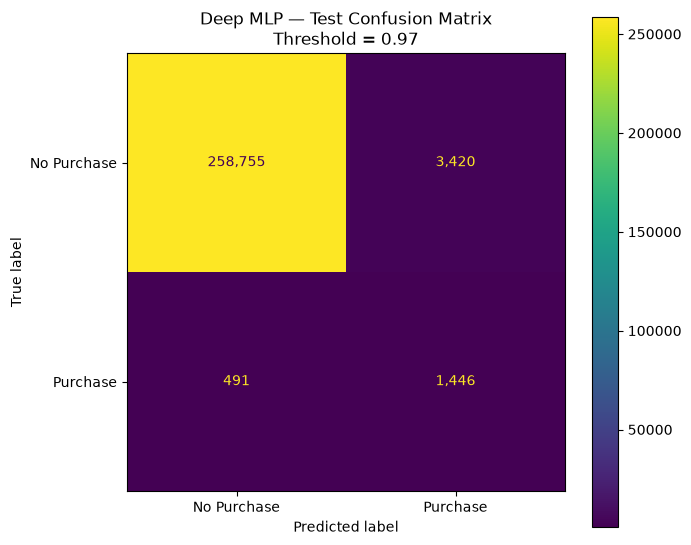

Confusion matrix saved successfully.
Path: C:\Users\user\OneDrive\Desktop\CC Project clone\Ecommerce-purchase-prediction-DeepLearning\results\mlp\mlp_confusion_matrix.png


In [19]:
# Cell 19 — Save final test confusion matrix

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(7, 6))

ConfusionMatrixDisplay(
    confusion_matrix=test_cm,
    display_labels=["No Purchase", "Purchase"]
).plot(
    ax=ax,
    values_format=",d"
)

ax.set_title(
    f"Deep MLP — Test Confusion Matrix\n"
    f"Threshold = {BEST_THRESHOLD:.2f}"
)

plt.tight_layout()

confusion_matrix_path = MLP_RESULTS_DIR / "mlp_confusion_matrix.png"

plt.savefig(
    confusion_matrix_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Confusion matrix saved successfully.")
print(f"Path: {confusion_matrix_path}")

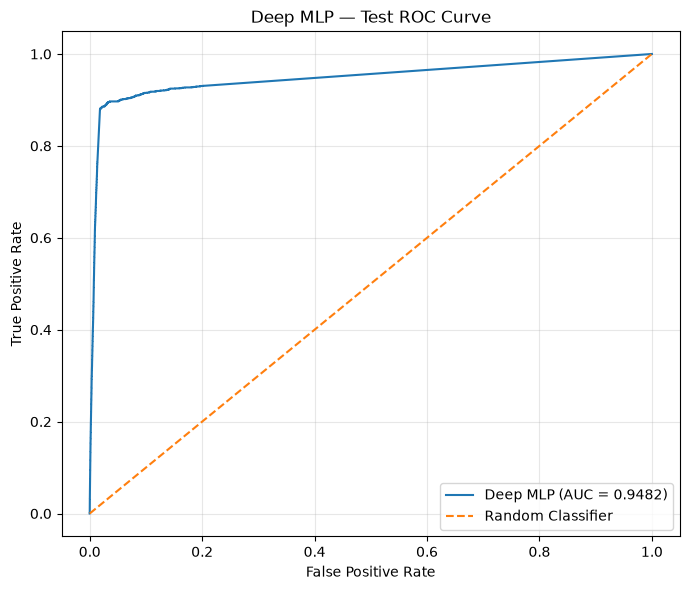

ROC curve saved successfully.
ROC-AUC: 0.9482
Path: C:\Users\user\OneDrive\Desktop\CC Project clone\Ecommerce-purchase-prediction-DeepLearning\results\mlp\mlp_roc_curve.png


In [20]:
# Cell 20 — Save final test ROC curve

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, roc_thresholds = roc_curve(
    y_test,
    test_probabilities
)

roc_auc_value = auc(fpr, tpr)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Deep MLP (AUC = {roc_auc_value:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Deep MLP — Test ROC Curve")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()

roc_curve_path = MLP_RESULTS_DIR / "mlp_roc_curve.png"

plt.savefig(
    roc_curve_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("ROC curve saved successfully.")
print(f"ROC-AUC: {roc_auc_value:.4f}")
print(f"Path: {roc_curve_path}")

In [21]:
# Cell 21 — Save training history

history_csv_path = MLP_RESULTS_DIR / "mlp_training_history.csv"

history_df.to_csv(
    history_csv_path,
    index=False
)

print("Training history saved successfully.")
print(f"Path: {history_csv_path}")
print(f"Rows: {len(history_df)}")
print(f"Columns: {list(history_df.columns)}")

Training history saved successfully.
Path: C:\Users\user\OneDrive\Desktop\CC Project clone\Ecommerce-purchase-prediction-DeepLearning\results\mlp\mlp_training_history.csv
Rows: 18
Columns: ['accuracy', 'auc', 'loss', 'precision', 'recall', 'val_accuracy', 'val_auc', 'val_loss', 'val_precision', 'val_recall', 'learning_rate']


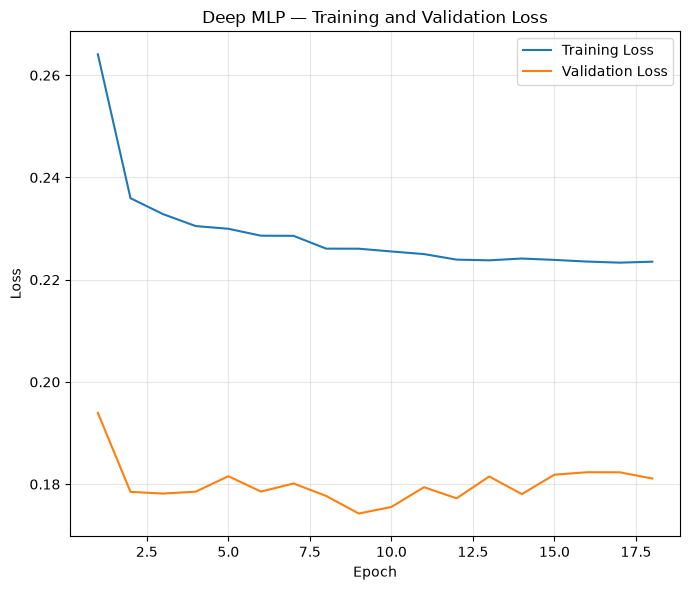

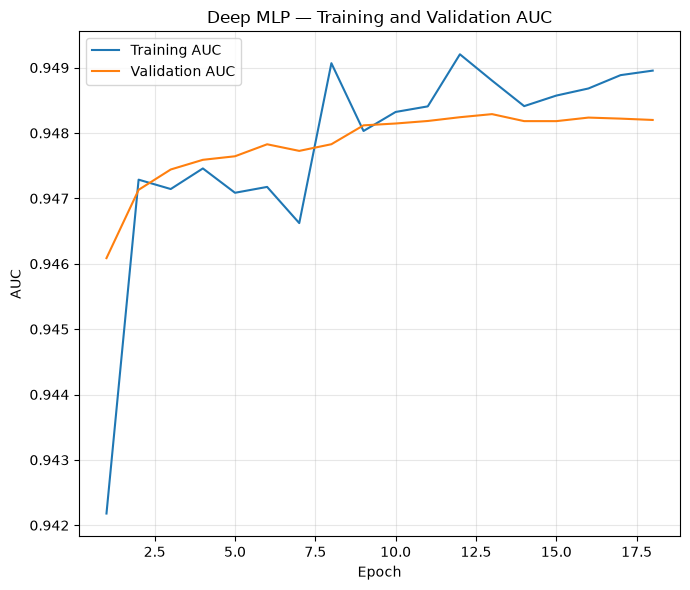

Training curves saved successfully.
Loss curve: C:\Users\user\OneDrive\Desktop\CC Project clone\Ecommerce-purchase-prediction-DeepLearning\results\mlp\mlp_loss_curve.png
AUC curve: C:\Users\user\OneDrive\Desktop\CC Project clone\Ecommerce-purchase-prediction-DeepLearning\results\mlp\mlp_auc_curve.png


In [22]:
# Cell 22 — Save MLP training curves

import matplotlib.pyplot as plt

epochs_range = range(1, len(history_df) + 1)

# Loss curve
plt.figure(figsize=(7, 6))
plt.plot(epochs_range, history_df["loss"], label="Training Loss")
plt.plot(epochs_range, history_df["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Deep MLP — Training and Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

loss_curve_path = MLP_RESULTS_DIR / "mlp_loss_curve.png"
plt.savefig(loss_curve_path, dpi=300, bbox_inches="tight")
plt.show()

# AUC curve
plt.figure(figsize=(7, 6))
plt.plot(epochs_range, history_df["auc"], label="Training AUC")
plt.plot(epochs_range, history_df["val_auc"], label="Validation AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("Deep MLP — Training and Validation AUC")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

auc_curve_path = MLP_RESULTS_DIR / "mlp_auc_curve.png"
plt.savefig(auc_curve_path, dpi=300, bbox_inches="tight")
plt.show()

print("Training curves saved successfully.")
print(f"Loss curve: {loss_curve_path}")
print(f"AUC curve: {auc_curve_path}")

In [23]:
# Cell 23 — Save the trained Deep MLP model

mlp_model_path = MLP_RESULTS_DIR / "deep_mlp.keras"

model.save(mlp_model_path)

print("Deep MLP model saved successfully.")
print(f"Path: {mlp_model_path}")

Deep MLP model saved successfully.
Path: C:\Users\user\OneDrive\Desktop\CC Project clone\Ecommerce-purchase-prediction-DeepLearning\results\mlp\deep_mlp.keras


In [24]:
# Cell 24 — Verify all saved MLP result files

from pathlib import Path

print("MLP RESULTS DIRECTORY")
print("-" * 50)

for file_path in sorted(MLP_RESULTS_DIR.iterdir()):
    if file_path.is_file():
        size_kb = file_path.stat().st_size / 1024
        print(f"{file_path.name:<35} {size_kb:,.1f} KB")

print("-" * 50)

expected_files = [
    "mlp_test_metrics.csv",
    "mlp_confusion_matrix.png",
    "mlp_roc_curve.png",
    "mlp_training_history.csv",
    "mlp_loss_curve.png",
    "mlp_auc_curve.png",
    "deep_mlp.keras"
]

missing_files = [
    file_name
    for file_name in expected_files
    if not (MLP_RESULTS_DIR / file_name).exists()
]

if not missing_files:
    print("ALL EXPECTED MLP FILES FOUND.")
else:
    print("Missing files:")
    for file_name in missing_files:
        print(f"- {file_name}")

MLP RESULTS DIRECTORY
--------------------------------------------------
deep_mlp.keras                      172.1 KB
mlp_auc_curve.png                   142.7 KB
mlp_confusion_matrix.png            83.8 KB
mlp_loss_curve.png                  108.8 KB
mlp_roc_curve.png                   129.5 KB
mlp_test_metrics.csv                0.3 KB
mlp_training_history.csv            3.9 KB
--------------------------------------------------
ALL EXPECTED MLP FILES FOUND.
